In [1]:
import numpy as np
import pickle
import pandas as pd
import scipy as sp
import scipy.stats as stats
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import matplotlib

from _helper_functions import cb
from _helper_functions import zipdf

from ast import literal_eval


import _helper_grammar_functions as jsgo

In [2]:
mDF=pd.read_csv('reference-files/doublets.csv')
mDF['real-data']=mDF['real-data'].apply(lambda s: literal_eval(s))
mDF['binding-sites']=mDF['binding-sites'].apply(lambda s: literal_eval(s))

mDF.head()

,Unnamed: 0,real-data,binding-sites,spacing
0,0,"(297, 1183, 669)","(E, E)",24
1,1,"(642, 2224, 1402)","(E, g)",56
2,2,"(356, 1601, 921)","(g, G)",33
3,3,"(776, 4788, 3197)","(G, G)",24
4,4,"(2170, 8041, 4725)","(g, G)",22


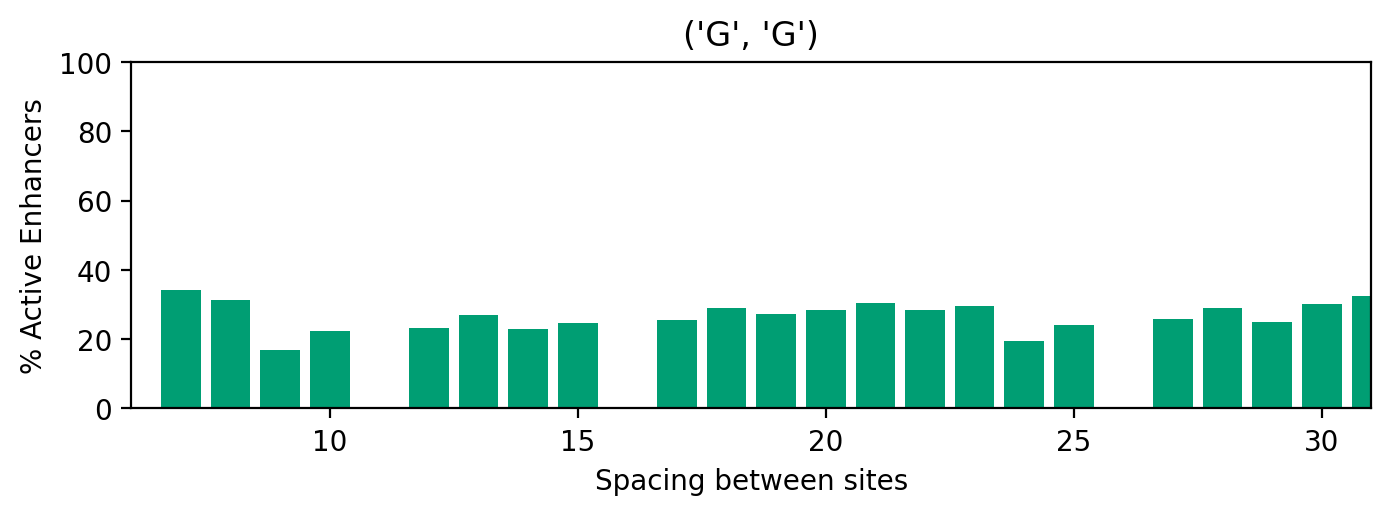

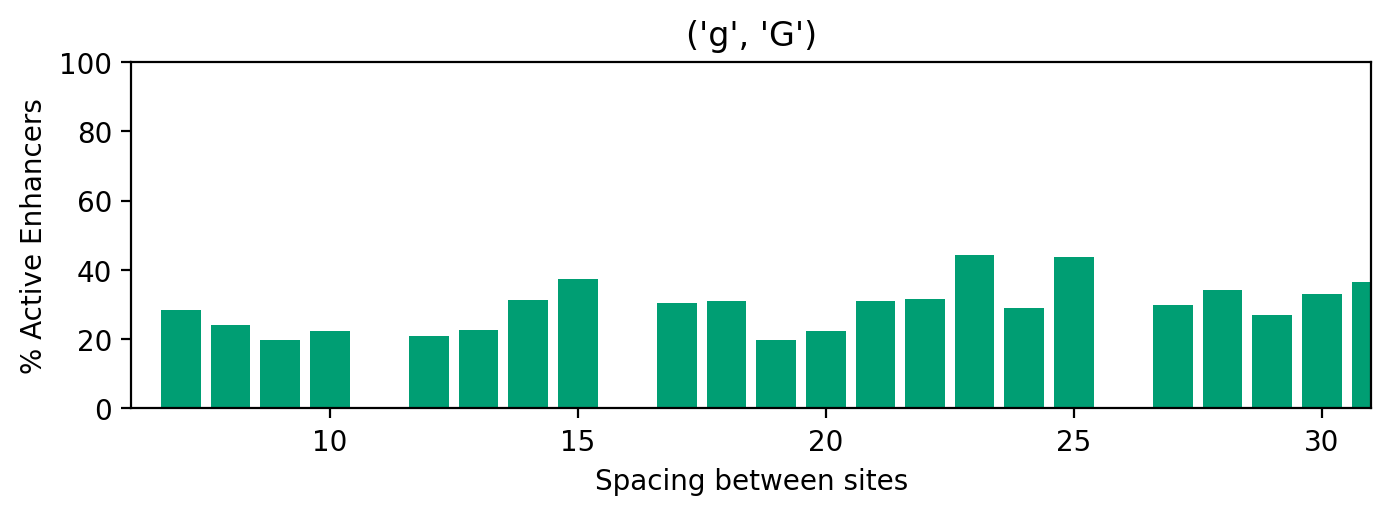

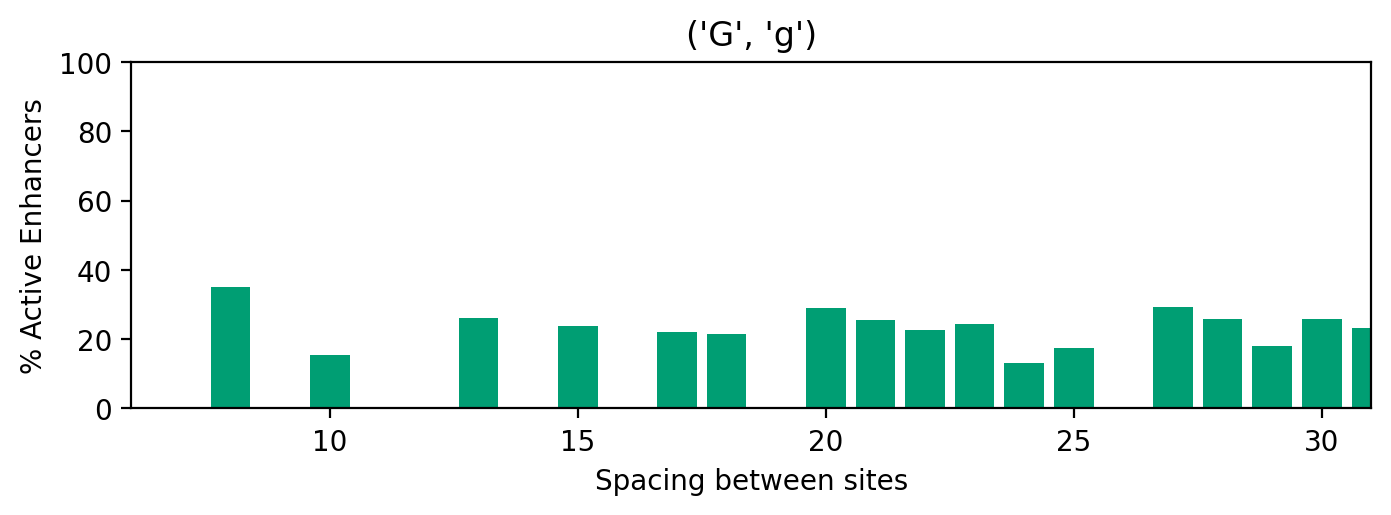

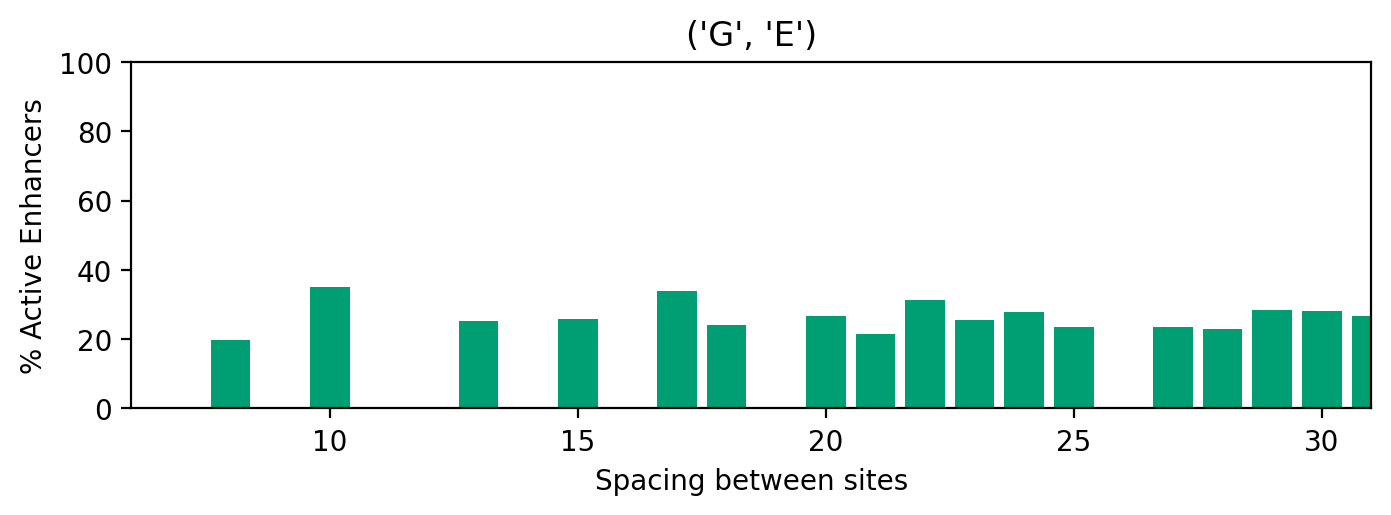

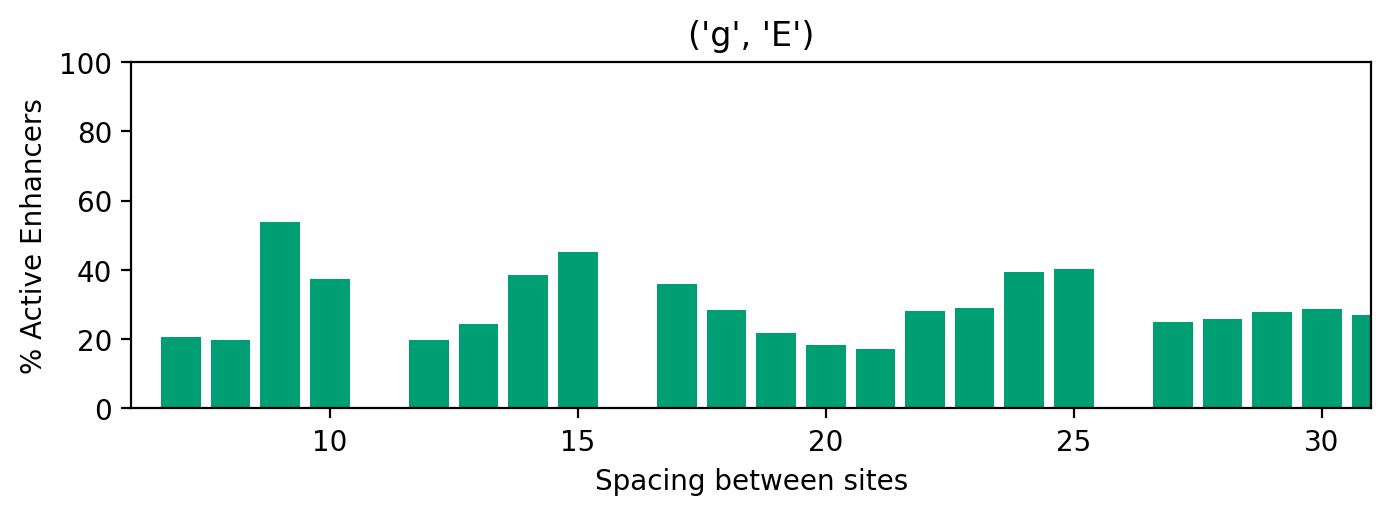

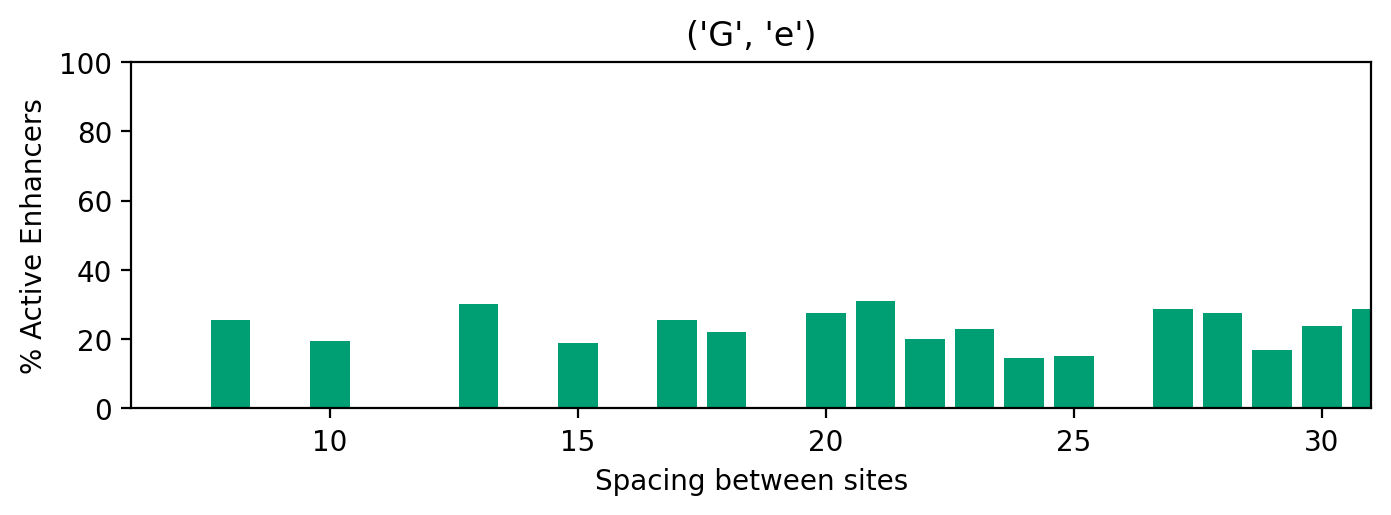

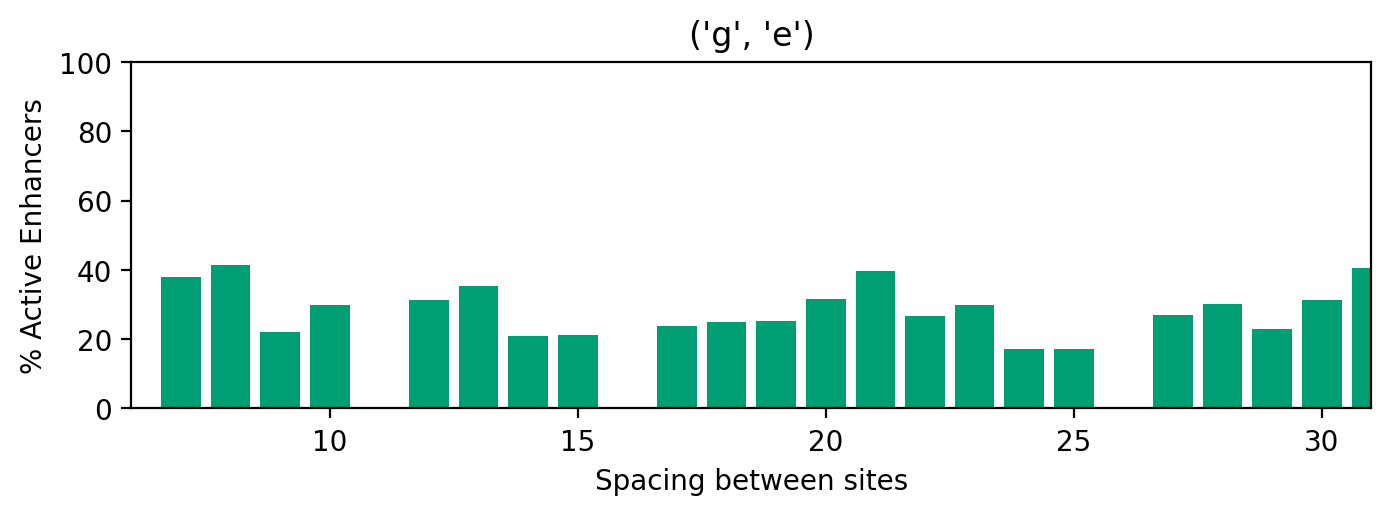

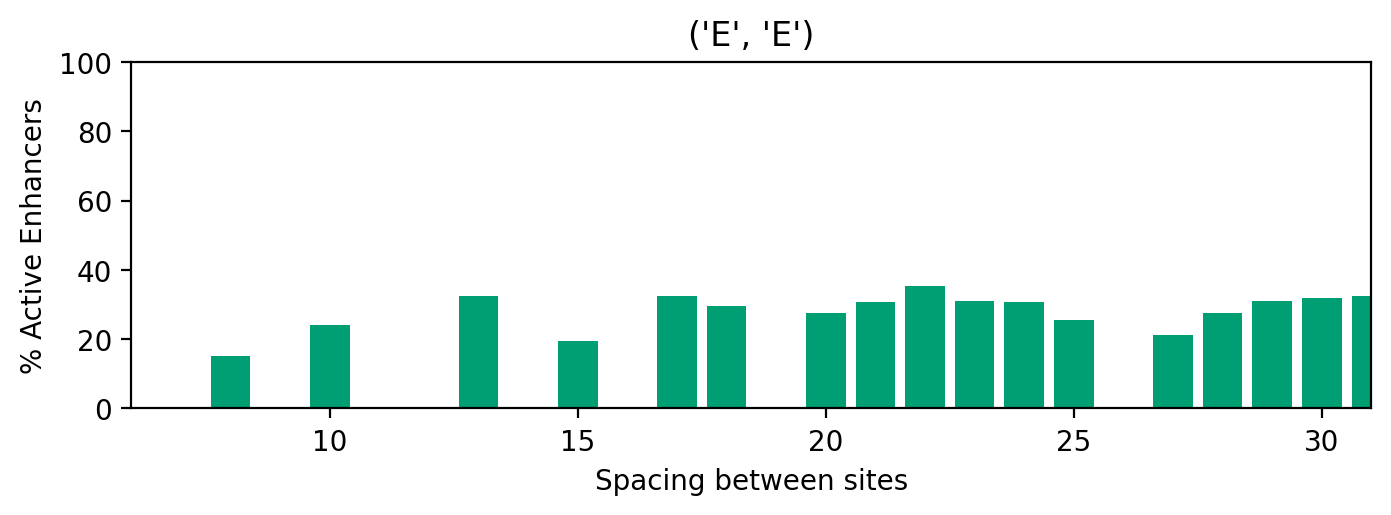

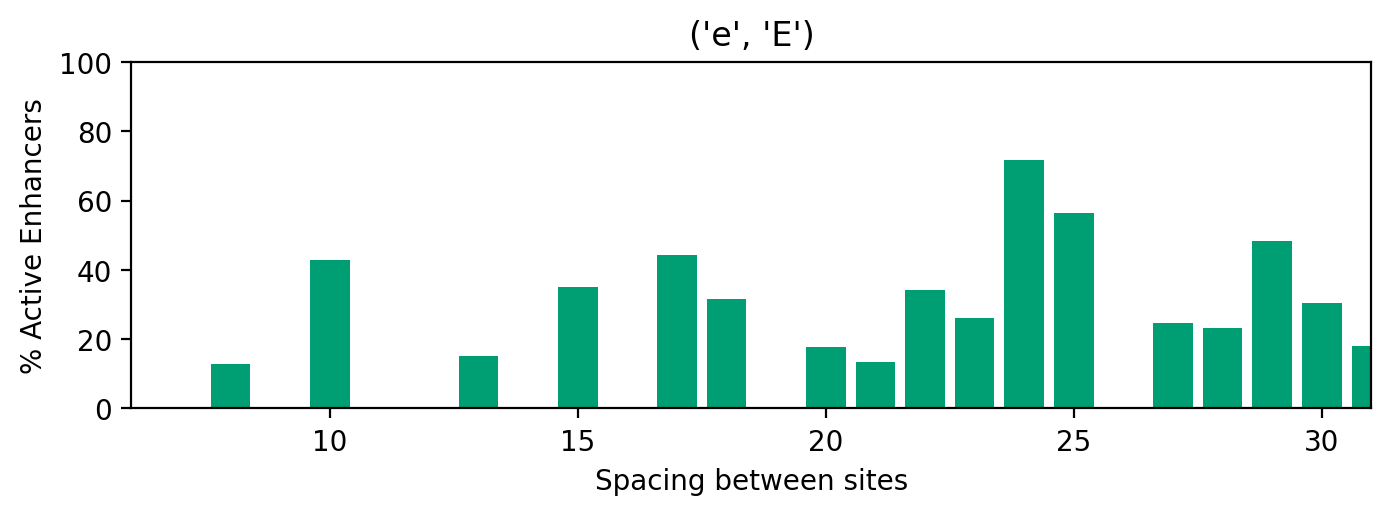

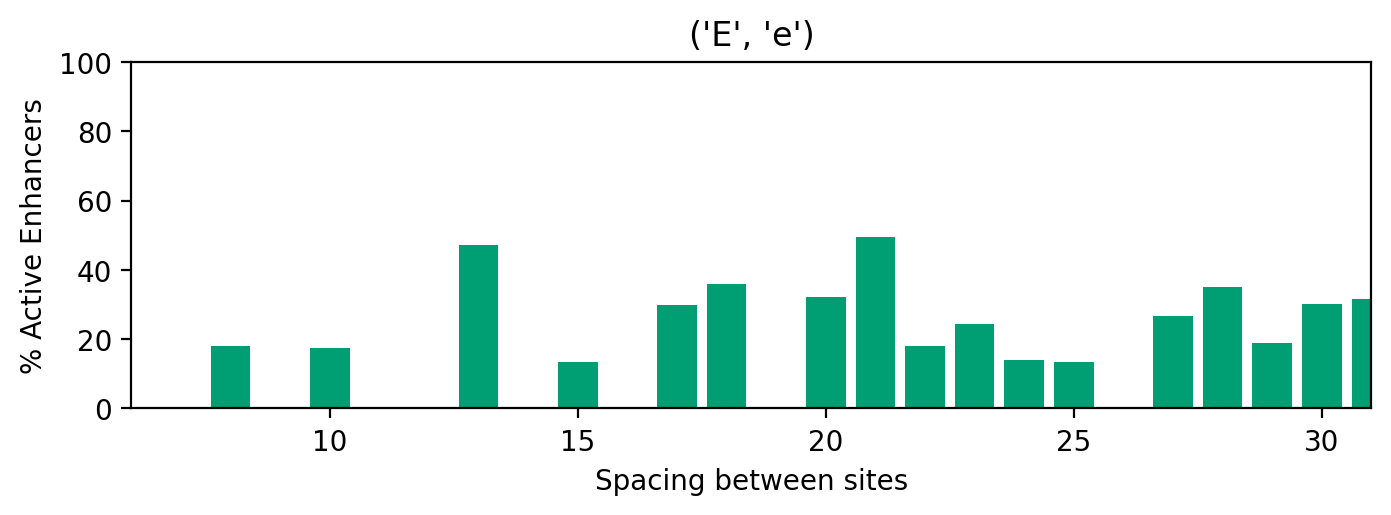

In [3]:
def plotspacings(sitetup,sitetupRC):

    global mDF

    siteFilter=[sitetup,sitetupRC]

    plotDF=mDF.loc[mDF['binding-sites'].isin(siteFilter),:].sort_values('spacing')

    fig,ax=plt.subplots(1,figsize=(8,2.25),dpi=200)
    
    for space,data in zipdf(plotDF,['spacing','real-data']):

        func,_,inert=data

        func=100*func/(func+inert)

        ax.bar(x=space,height=func,color=cb['green'])

    ax.set_xlim(6,31)
    ax.set_ylim(0,100)
    ax.set_title(sitetup)
    ax.set_ylabel('% Active Enhancers')
    ax.set_xlabel('Spacing between sites')
    plt.show()


orders=['GG','GE','EG','EE']

ordOriMotifsAnalyzed=set()

for s1,s2 in orders:

    for i,j in [[0,0],[1,0],[0,1],[1,1]]:

        if i==1: site1=s1.lower()
        else:    site1=s1

        if j==1: site2=s2.lower()
        else:    site2=s2

        ordOriMotif=f'ord_ori={site1}_{site2}'
        
        if (ordOriMotif in ordOriMotifsAnalyzed) or (jsgo.motif_revcomp_with_phrasetype(ordOriMotif) in ordOriMotifsAnalyzed):
            continue
        else:
            ordOriMotifsAnalyzed.add(ordOriMotif)
            
        # print(site1,site2)
        revSites=jsgo.motif_revcomp_with_phrasetype(ordOriMotif)
        revSites=revSites.split('=')[-1].split('_')
        rc1,rc2=revSites

        # print(site1,site2,'   ',rc1,rc2)
        plotspacings((site1,site2),(rc1,rc2))

